# Aggregate Data Analysis
<br>
Objectives:
<br>
1. Are there any highly correlated (80%+) fields that should be condensed down to only one of them being included?
<br>
2. Are there any features that should be added that we don’t currently include
 (look at global_schema in /src/repositories/graphs/pyg_builder.py to see current fields being used)?
<br>
3. What does the distribution of “port_number” look like?
<br>
4. What is the overall range?
<br>
5. Do they naturally cluster into distinct groups?<br>
<br>
Data Source:
<br>
Collected from an automated industrial monitoring system, containing timestamped readings of tank levels, pump states, valve activations, flow sensor outputs, and labeled system states.
<br> <br>
File: testbed_system_1_network_aggregated.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
try:
    df = pd.read_csv('/content/drive/MyDrive/CS/AI Cybersecurity/LinkedData/testbed_system_1_network_aggregated.csv', sep=",", encoding='utf-8', engine="python")
except UnicodeDecodeError:
        print("UnicodeDecodeError")

#Part I - Aggregated Fields

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352216 entries, 0 to 352215
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   bucket                     352216 non-null  object 
 1   system_id                  352216 non-null  object 
 2   protocol                   352216 non-null  object 
 3   avg_size                   352216 non-null  float64
 4   source_total_packets       352216 non-null  int64  
 5   destination_total_packets  352216 non-null  int64  
 6   min_size                   352216 non-null  int64  
 7   max_size                   352216 non-null  int64  
 8   num_connections            352216 non-null  int64  
 9   source_ip                  351921 non-null  object 
 10  source_port                351852 non-null  float64
 11  source_mac                 352216 non-null  object 
 12  destination_ip             351921 non-null  object 
 13  destination_port           35

In [ ]:
print(df.head())

                      bucket         system_id protocol   avg_size  \
0  2021-04-09 11:30:30+00:00  testbed_system_1      TCP  60.857143   
1  2021-04-09 11:30:30+00:00  testbed_system_1      TCP  71.600000   
2  2021-04-09 11:30:30+00:00  testbed_system_1      TCP  60.000000   
3  2021-04-09 11:30:30+00:00  testbed_system_1      TCP  60.857143   
4  2021-04-09 11:30:30+00:00  testbed_system_1      TCP  68.666667   

   source_total_packets  destination_total_packets  min_size  max_size  \
0                    51                        120        60        66   
1                    73                         10        66        78   
2                    42                        103        60        60   
3                    44                        121        60        66   
4                   103                        105        66        74   

   num_connections     source_ip  source_port         source_mac  \
0                7   84.3.251.18        502.0  00:80:f4:03:fb:12  

In [ ]:
# Correlation matrix -- highly-correlated fields
numeric_fields = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_fields.corr()

# Filter for values above 0.8
high_corr = corr_matrix[(corr_matrix > 0.8) & (corr_matrix < 1.0)]
print(high_corr.dropna(how='all').dropna(axis=1, how='all'))

                           avg_size  source_total_packets  \
avg_size                        NaN                   NaN   
source_total_packets            NaN                   NaN   
destination_total_packets       NaN              0.978985   
min_size                   0.969459                   NaN   
max_size                   0.955285                   NaN   
num_connections                 NaN              0.966456   

                           destination_total_packets  min_size  max_size  \
avg_size                                         NaN  0.969459  0.955285   
source_total_packets                        0.978985       NaN       NaN   
destination_total_packets                        NaN       NaN       NaN   
min_size                                         NaN       NaN  0.875872   
max_size                                         NaN  0.875872       NaN   
num_connections                             0.987075       NaN       NaN   

                           num_connecti

#Part II – Visuals for Aggregated Fields

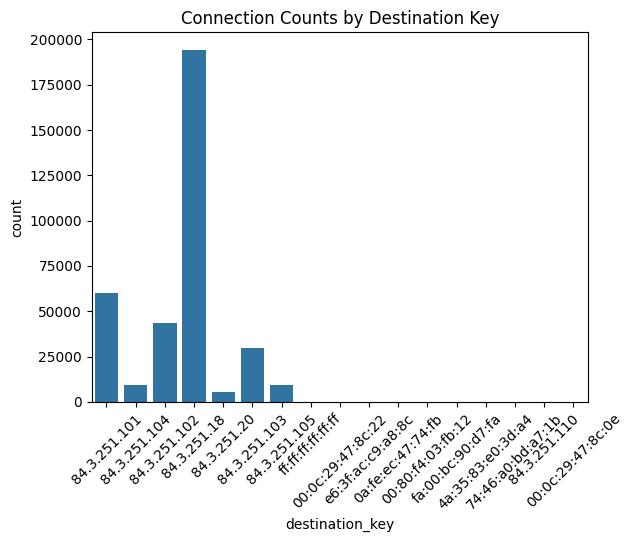

In [ ]:
# Bar chart -- connection counts per system/protocol, source key and destination key
sns.countplot(data=df, x='destination_key')
plt.title("Connection Counts by Destination Key")
plt.xticks(rotation=45)
plt.show()

This bar chart can reveal dominant protocols/systems depending on the input fields.

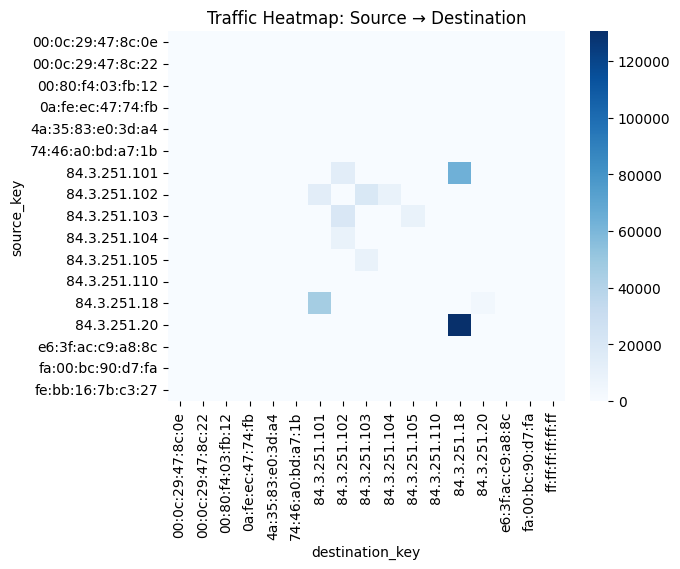

In [ ]:
# Heatmap -- source vs. destination frequency
heatmap_data = df.groupby(['source_key', 'destination_key']).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, cmap='Blues')
plt.title("Traffic Heatmap: Source → Destination")
plt.show()

This heatmap reveals which nodes communicate most frequently and can be bucketed by time to conduct temporal analysis.

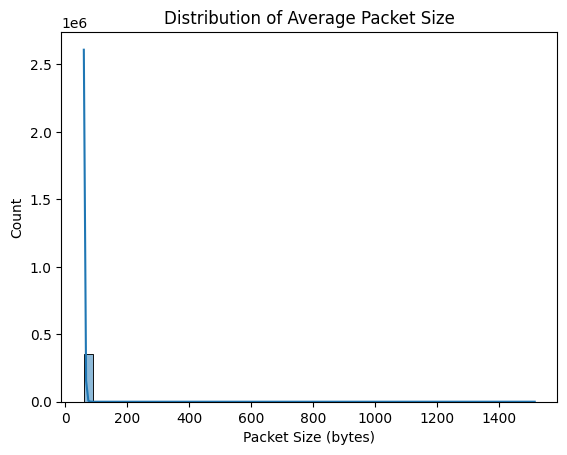

In [ ]:
# Histogram -- packet size distribution
sns.histplot(df['avg_size'], bins=50, kde=True)
plt.title("Distribution of Average Packet Size")
plt.xlabel("Packet Size (bytes)")
plt.show()

This histogram shows typical vs. anomalous packet sizes.

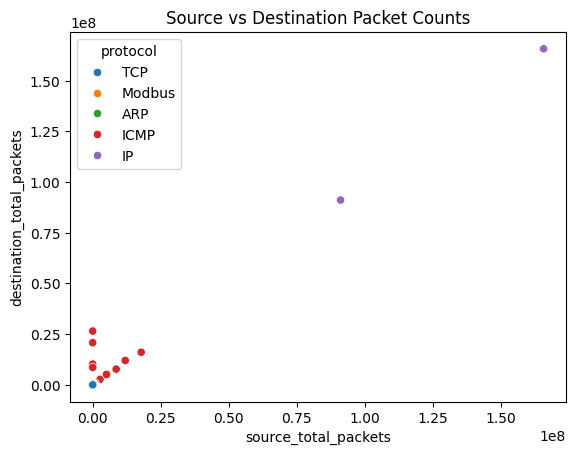

In [ ]:
# Scatter plot -- source vs. destination packet counts
sns.scatterplot(data=df, x='source_total_packets', y='destination_total_packets', hue='protocol')
plt.title("Source vs Destination Packet Counts")
plt.show()

This scatter plot reveals asymmetry, clustering and outliers of the packets.

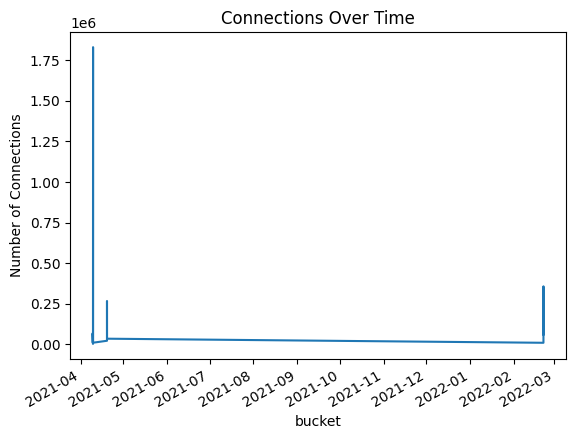

In [ ]:
# Time series plot -- connections over time
df['bucket'] = pd.to_datetime(df['bucket'])
time_series = df.groupby('bucket')['num_connections'].sum()
time_series.plot()
plt.title("Connections Over Time")
plt.ylabel("Number of Connections")
plt.show()

This time series plot shows traffic spikes, trends and anomalies.

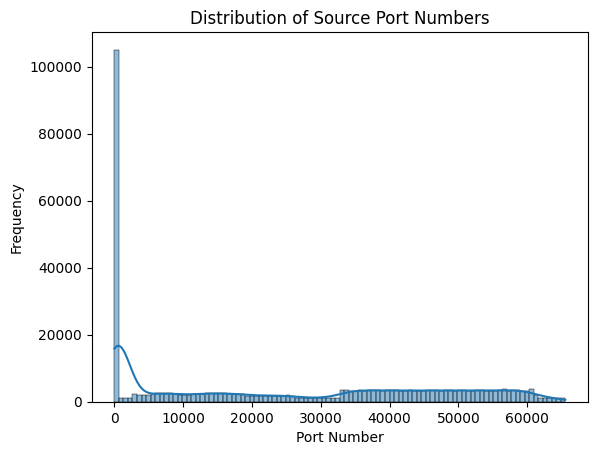

In [ ]:
# Histogram/KDE plot -- reveal clustering of source port numbers
sns.histplot(df['source_port'].dropna(), bins=100, kde=True)
plt.title("Distribution of Source Port Numbers")
plt.xlabel("Port Number")
plt.ylabel("Frequency")
plt.show()